In [1]:
!pip install pgmpy pygad scikit-learn fairlearn networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.1 MB/s eta 0:00:000:00:0100:01
  Attempting uninstall: nvidia-nvjitli

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from fairlearn.metrics import (demographic_parity_difference, 
                               equalized_odds_difference, 
                               true_positive_rate_difference, 
                               false_positive_rate_difference)
from fairlearn.metrics import MetricFrame
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import sparse
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination


In [3]:
def preprocessAdultIncome():
    data = pd.read_csv('/kaggle/input/adult-census-income/adult.csv') #load dataset
    # print(data.columns)
    categorical_cols = ['workclass', 'education', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']
    numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
    data["income"] = np.where(data["income"] == ">50K", 1, 0) #convert to binary vals
    # print(data.head())
    column_names = data.columns
    # for i in column_names: #this was to see the missing vals
        # print(i,(data[i] == '?').sum()) #workclass, occupation and native.country have ? vals
    missing_vals = data.isin(['?']).any(axis=1) #find missing vals 
    # print(data[missing_vals]['income'].value_counts()) #see how many missing vals are there in each class, doesnt matter that much, the difference
    data = data[~missing_vals] #drop missing vals
    data.reset_index(drop=True, inplace=True)
    # print(data["income"].value_counts())
    #below is for proportional upsampling
    more_50k = data[data['income']==1] #all that is 1 vals
    # print(more_50k.groupby(['race','sex']).size()) #how many vals by each of the race and sex group
    dist = more_50k.groupby(['race','sex']).size().reset_index(name='count') #this is the count of the current distribution of vals 
    # print((dist['count']*22654/dist['count'].sum()).round().astype(int))
    dist['up_count'] = (dist['count']*22654/dist['count'].sum()).round().astype(int) #calulates to what rate we need to upsample to keep the proportion of bias and reach the goal no of samples
    # print(dist.head())
    upsampled_list = []
    for _,row in dist.iterrows():
        sex = row["sex"]
        race = row["race"]
        up_count = row["up_count"]
        group_df = more_50k[(more_50k['sex']==sex) & (more_50k['race']==race)] #group for a particular race and sex combo
        upsampled_group = resample(group_df, replace = True, n_samples = up_count, random_state = 42) #resample to reach the up_count
        upsampled_list.append(upsampled_group)
    upsampled_more_than_50k = pd.concat(upsampled_list)
    less_than_50k = data[data['income']==0]
    df = pd.concat([less_than_50k,upsampled_more_than_50k]).sample(frac=1,random_state=42).reset_index(drop=True) #concat with shuffle (frac=1 makes it so all of the samples are considered)
    df.head()
    print(df["income"].value_counts())
    print(df['sex'].value_counts())
    #preprocessing pipeline
    numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('category', OneHotEncoder(handle_unknown='ignore'))])
    preprocessor = ColumnTransformer(transformers=[
        ('num',numeric_transformer,numeric_cols),
        ('cat',categorical_transformer,categorical_cols)
    ])
    #mapping sensitive attributes but not using it for first pass
    #IS THIS ALREADY ONE HOT ENCODED?????????????????
    race_mapping = {"White": 0,"Black": 1,"Asian-Pac-Islander": 2,"Amer-Indian-Eskimo": 3,"Other": 4}
    sensitive_race = df["race"].map(race_mapping)
    sex_mapping = {"Male": 0, "Female": 1}
    sensitive_sex = df["sex"].map(sex_mapping)
    #train test split
    X = df.drop(["income"],axis=1)
    y = df["income"].values
    X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sensitive_race_train, sensitive_race_test = train_test_split(sensitive_race, test_size=0.2, random_state=42, stratify=y)
    sensitive_sex_train, sensitive_sex_test = train_test_split(sensitive_sex, test_size=0.2, random_state=42, stratify=y)
    #implement the preprocessing
    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)
    return X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test 


In [4]:
X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test = preprocessAdultIncome()

income
1    22654
0    22654
Name: count, dtype: int64
sex
Male      33283
Female    12025
Name: count, dtype: int64


**AUR METRICS GHUSAANE HAI TOH GHUSAOOO**

In [5]:
def four_metrics(y_test, y_pred, sensitive_race_test, sensitive_sex_test):
    race_metrics = {
        "Demographic Parity Difference": demographic_parity_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "Equalized Odds Difference": equalized_odds_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "Equal Opportunity Difference": true_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test),
        "False Positive Rate Difference": false_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_race_test)
    }
    sex_metrics = {
        "Demographic Parity Difference": demographic_parity_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "Equalized Odds Difference": equalized_odds_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "Equal Opportunity Difference": true_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test),
        "False Positive Rate Difference": false_positive_rate_difference(
            y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_sex_test)
    }
    return race_metrics, sex_metrics

In [6]:
def base_model():
    print("THIS IS BASE MODEL.")
    base_model = LogisticRegression(max_iter=1000,random_state=42)
    base_model.fit(X_train,y_train)
    base_model_pred= base_model.predict(X_test)
    print("Accuracy", accuracy_score(y_test,base_model_pred))
    # print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    # print("Classification Report:\n", classification_report(y_test, y_pred))
    met_race, met_sex = four_metrics(y_test, base_model_pred, sensitive_race_test, sensitive_sex_test)
    print("Fairness metrics for Race:")
    for metric_name, value in met_race.items():
        print(f"{metric_name}: {value:.3f}")
    print("Fairness metrics for Sex:")
    for metric_name, value in met_sex.items():
        print(f"{metric_name}: {value:.3f}")
    return base_model_pred
base_model_pred = base_model()

THIS IS BASE MODEL.
Accuracy 0.8177002869123814
Fairness metrics for Race:
Demographic Parity Difference: 0.370
Equalized Odds Difference: 0.280
Equal Opportunity Difference: 0.146
False Positive Rate Difference: 0.280
Fairness metrics for Sex:
Demographic Parity Difference: 0.373
Equalized Odds Difference: 0.226
Equal Opportunity Difference: 0.141
False Positive Rate Difference: 0.226



**Below is the aggresive hard reweighting we applied before. can we implement a softer reweighting if need be?also how does it get worse for eq odds and eq opportunity? i think its because of the tpr, how can we fix that? is this a fair tradeoff?**


In [7]:
def hard_reweighting(y_pred):
    adjusted_preds = y_pred.copy()
    for sensitive_attr in [sensitive_race_test, sensitive_sex_test]:
        #group is group within a sensitive atrr
        df = pd.DataFrame({'group': sensitive_attr, 'pred': adjusted_preds})
        # print(df.sample(10))
        selection_rates = df.groupby('group')['pred'].mean()
        #this is basically the num of 1's for a particular group, this is supposed to indicate how many times a part grp gets picked on an avg
        # print(selection_rates)
        target_rate = selection_rates.mean()
        #mean of all selection rates is our target
        # print(target_rate)
        for group, rate in selection_rates.items():
            # print("group,rate", group,rate)
            adjustment = target_rate - rate
            idxs = np.where(df['group'] == group)[0]
            #indices of the part group wherver they are
            group_preds = adjusted_preds[idxs] #only preds of that group are in this var
            if adjustment > 0: #+ve adjustment -> need to reduce 1's, pick 0 as candidate
                flip_candidates = idxs[group_preds == 0]
            else: #-ve adjustment -> need to increase 1's, pick 1 as candidate
                flip_candidates = idxs[group_preds == 1]
            #num to flip is how many predictions to actually flip 
            #1st candidate is adjs rate * total (basically diff in num)
            #2nd is total preds that fit the criteria (i.e all 0s or 1s)
            num_to_flip = min(int(abs(adjustment) * len(idxs)), len(flip_candidates))
            if num_to_flip > 0:
                #randomly pick WHICH candidates to flip, but we calc the NUM OF CANDIDATES to flip
                np.random.seed(42)
                flip_idxs = np.random.choice(flip_candidates, size=num_to_flip, replace=False)
                adjusted_preds[flip_idxs] = 1 if adjustment > 0 else 0
    return adjusted_preds


In [8]:
print("HARD STATISTICAL REWEIGHTING")
adjusted_hard_preds = hard_reweighting(base_model_pred)
print("Accuracy", accuracy_score(y_test,adjusted_hard_preds))
met_race, met_sex = four_metrics(y_test, adjusted_hard_preds, sensitive_race_test, sensitive_sex_test)
print("Fairness metrics for Race:")
for metric_name, value in met_race.items():
    print(f"{metric_name}: {value:.3f}")
print("Fairness metrics for Sex:")
for metric_name, value in met_sex.items():
    print(f"{metric_name}: {value:.3f}")

HARD STATISTICAL REWEIGHTING
Accuracy 0.6412491723681306
Fairness metrics for Race:
Demographic Parity Difference: 0.083
Equalized Odds Difference: 0.219
Equal Opportunity Difference: 0.219
False Positive Rate Difference: 0.080
Fairness metrics for Sex:
Demographic Parity Difference: 0.000
Equalized Odds Difference: 0.151
Equal Opportunity Difference: 0.151
False Positive Rate Difference: 0.058


> i have to check, the split of train test and even of sensitive attr. the train set isnt used anywhere cause it needs the size to be the same, so i just end up using the test set everywhere. i have to check

BUILD BBN
Discretizing age from 72 values to 5 bins
Discretizing hours_per_week from 94 values to 5 bins
Discretizing education_num from 16 values to 5 bins
Added node: age
Added node: hours_per_week
Added node: education_num
Added node: race
Added node: sex
Added node: income
Added edge: race -> age
Added edge: race -> hours_per_week
Added edge: race -> education_num
Added edge: sex -> age
Added edge: sex -> hours_per_week
Added edge: sex -> education_num
Added edge: age -> education_num
Added edge: education_num -> hours_per_week
Added edge: age -> income
Added edge: hours_per_week -> income
Added edge: education_num -> income
Added edge: race -> income
Added edge: sex -> income
Estimating CPDs using MLE...
Estimating CPD for age (Cardinality: 5)
Added CPD for age
Estimating CPD for hours_per_week (Cardinality: 5)
Added CPD for hours_per_week
Estimating CPD for education_num (Cardinality: 5)
Added CPD for education_num
Estimating CPD for race (Cardinality: 6)
Added CPD for race
Estim

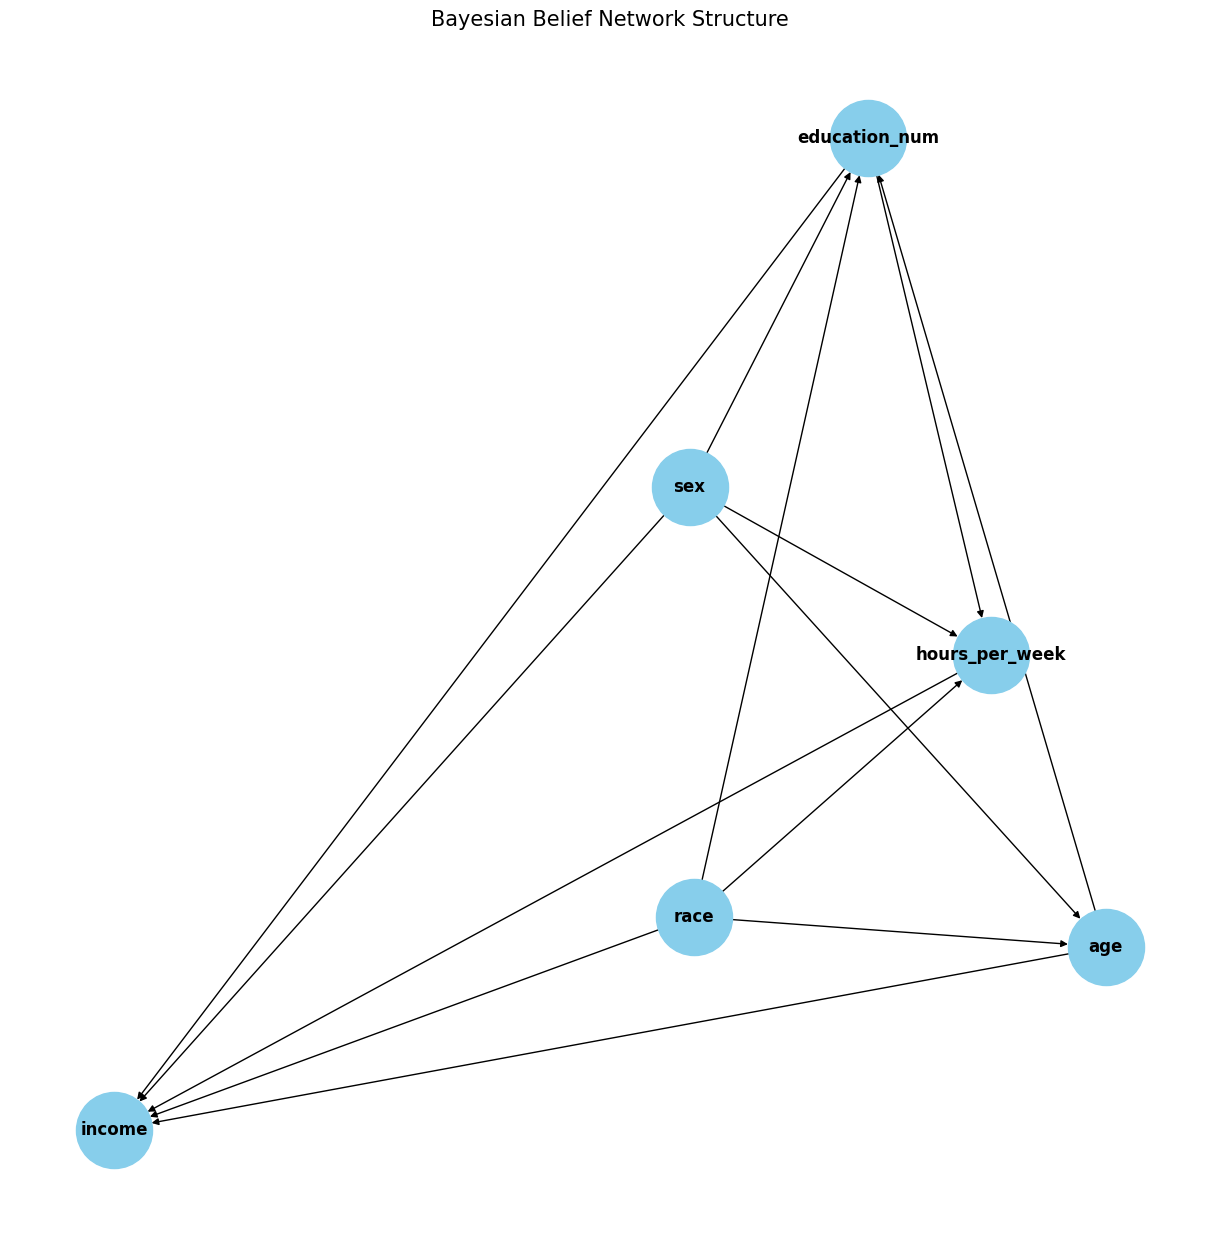


Example inference capabilities:
1. Query probability of income=1 given race=0, sex=0, education_num=4:
   P(income=1 | race=0, sex=0, education_num=4) = 0.6351


In [9]:
def visualize_bbn(bbn):
    G = nx.DiGraph()
    for node in bbn.nodes():
        G.add_node(node)
    for edge in bbn.edges():
        G.add_edge(*edge)
    pos = nx.spring_layout(G)
    plt.figure(figsize=(12, 12))
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=12, font_weight='bold', arrows=True)
    plt.title('Bayesian Belief Network Structure', fontsize=15)
    plt.show()

def build_bbn(X_train, y_train, sensitive_race_train, sensitive_sex_train, numeric_cols, categorical_cols):
    print("BUILD BBN")
    #convert to dense array to store all vals
    X_train = X_train.toarray() 
    df_train = pd.DataFrame(X_train, columns=[f"feature_{i}" for i in range(X_train.shape[1])])
    # Mapping numeric columns to specific feature names
    specific_features = {
        'age': 0,        
        'hours_per_week': 5,  
        'education_num': 2  
    }
    df = pd.DataFrame()
    for feature_name, col_idx in specific_features.items():
        if col_idx < X_train.shape[1]:
            df[feature_name] = df_train[f"feature_{col_idx}"]
    # Add sensitive attributes and target
    df['race'] = sensitive_race_train.astype(int)
    df['sex'] = sensitive_sex_train.astype(int)
    df['income'] = y_train.astype(int)
    # Discretize numeric features
    for col in ['age', 'hours_per_week', 'education_num']:
        if col in df.columns:
            unique_vals = df[col].nunique()
            if unique_vals > 5:
                print(f"Discretizing {col} from {unique_vals} values to 5 bins")
                df[col] = pd.qcut(df[col].rank(method='first'), 5, labels=False)
    # Convert categorical variables to integer representations
    for col in df.columns:
        value_map = {val: i for i, val in enumerate(df[col].unique())}
        df[col] = df[col].map(value_map)
    # Create the Bayesian network
    bbn = DiscreteBayesianNetwork()
    # Add all columns as nodes
    for col in df.columns:
        bbn.add_node(col)
        print(f"Added node: {col}")
    # Define edges based on complex dependencies
    edges = []
    for sens in ['race', 'sex']:
        for feat in ['age', 'hours_per_week', 'education_num']:
            if feat in df.columns:
                edges.append((sens, feat))
                print(f"Added edge: {sens} -> {feat}")
    # Add feature interactions
    edges.append(('age', 'education_num'))
    print("Added edge: age -> education_num")
    edges.append(('education_num', 'hours_per_week'))
    print("Added edge: education_num -> hours_per_week")
    # Features affecting income
    for col in df.columns:
        if col != 'income':
            edges.append((col, 'income'))
            print(f"Added edge: {col} -> income")
    bbn.add_edges_from(edges)
    mle = MaximumLikelihoodEstimator(model=bbn, data=df)
    print("Estimating CPDs using MLE...")
    for node in bbn.nodes():
        card = len(df[node].unique())
        print(f"Estimating CPD for {node} (Cardinality: {card})")
        cpd = mle.estimate_cpd(node)
        bbn.add_cpds(cpd)
        print(f"Added CPD for {node}")
    print("Checking BBN model validity...")
    if bbn.check_model():
        print("BBN successfully built and validated!")
    else:
        print("Model validation failed.")
    # Visualization
    visualize_bbn(bbn)
        # Inference engine for query examples
    inference = VariableElimination(bbn)
    print("\nExample inference capabilities:")
    print("1. Query probability of income=1 given race=0, sex=0, education_num=4:")
    result = inference.query(variables=['income'], evidence={'race': 0, 'sex': 0, 'education_num': 4})
    print(f"   P(income=1 | race=0, sex=0, education_num=4) = {result.values[1]:.4f}")
    return bbn



    
# Example usage:
numeric_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
categorical_cols = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

# Assuming X_train, y_train, sensitive_race_train, sensitive_sex_train are predefined
bbn = build_bbn(
    X_train, 
    y_train, 
    sensitive_race_train, 
    sensitive_sex_train, 
    numeric_cols, 
    categorical_cols
)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import sparse

2025-04-22 07:00:50.764420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745305250.988141      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745305251.055040      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [11]:
def create_fairness_model(input_dim, embedding_dim=32):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(64, activation='relu')(inputs)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    embeddings = tf.keras.layers.Dense(embedding_dim, activation='relu', name='embeddings')(x)
    x = tf.keras.layers.Dense(16, activation='relu')(embeddings)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    encoder = tf.keras.Model(inputs=inputs, outputs=embeddings)
    
    return model, encoder

In [ ]:
def train_adversarial_model(X_train, y_train, race_train, sex_train, X_test, y_test, race_test, sex_test):
    if isinstance(race_train, pd.Series):
        race_train = race_train.values
    if isinstance(sex_train, pd.Series):
        sex_train = sex_train.values
    if isinstance(race_test, pd.Series):
        race_test = race_test.values
    if isinstance(sex_test, pd.Series):
        sex_test = sex_test.values
    
    if sparse.issparse(X_train):
        X_train = X_train.toarray()
    if sparse.issparse(X_test):
        X_test = X_test.toarray()
    
    input_dim = X_train.shape[1]
    embedding_dim = 32
    batch_size = 128
    epochs = 12
    fairness_weight = 2.0
    
    model, encoder = create_fairness_model(input_dim, embedding_dim)
    
    race_classifier = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(int(np.max(race_train)) + 1, activation='softmax')
    ])
    
    sex_classifier = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(int(np.max(sex_train)) + 1, activation='softmax')
    ])
    
    main_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    adv_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    
    income_loss_fn = tf.keras.losses.BinaryCrossentropy()
    class_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    
    best_fairness_score = float('inf')
    patience = 3
    patience_counter = 0
    
    for epoch in range(epochs):
        indices = np.random.permutation(len(X_train))
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        race_shuffled = race_train[indices]
        sex_shuffled = sex_train[indices]
        
        num_batches = int(np.ceil(len(X_train) / batch_size))
        epoch_income_loss = 0
        epoch_adv_loss = 0
        
        for batch in range(num_batches):
            start_idx = batch * batch_size
            end_idx = min(start_idx + batch_size, len(X_train))
            
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            race_batch = race_shuffled[start_idx:end_idx]
            sex_batch = sex_shuffled[start_idx:end_idx]
            
            X_batch_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
            y_batch_tensor = tf.convert_to_tensor(y_batch, dtype=tf.float32)
            race_batch_tensor = tf.convert_to_tensor(race_batch, dtype=tf.int32)
            sex_batch_tensor = tf.convert_to_tensor(sex_batch, dtype=tf.int32)
            
            for _ in range(3):
                with tf.GradientTape() as adv_tape:
                    embeddings = encoder(X_batch_tensor, training=False)
                    race_preds = race_classifier(embeddings, training=True)
                    sex_preds = sex_classifier(embeddings, training=True)
                    
                    race_adv_loss = class_loss_fn(race_batch_tensor, race_preds)
                    sex_adv_loss = class_loss_fn(sex_batch_tensor, sex_preds)
                    adv_loss = race_adv_loss + sex_adv_loss
                
                adv_vars = race_classifier.trainable_variables + sex_classifier.trainable_variables
                adv_grads = adv_tape.gradient(adv_loss, adv_vars)
                adv_optimizer.apply_gradients(zip(adv_grads, adv_vars))
            
            with tf.GradientTape() as main_tape:
                y_pred = model(X_batch_tensor, training=True)
                embeddings = encoder(X_batch_tensor, training=True)
                race_preds = race_classifier(embeddings, training=False)
                sex_preds = sex_classifier(embeddings, training=False)
                
                income_loss = income_loss_fn(y_batch_tensor, y_pred)
                race_adv_loss = class_loss_fn(race_batch_tensor, race_preds)
                sex_adv_loss = class_loss_fn(sex_batch_tensor, sex_preds)
                adv_loss = race_adv_loss + sex_adv_loss
                
                total_loss = income_loss - fairness_weight * adv_loss
            
            main_vars = model.trainable_variables
            main_grads = main_tape.gradient(total_loss, main_vars)
            
            main_grads = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in main_grads]
            main_optimizer.apply_gradients(zip(main_grads, main_vars))
            
            epoch_income_loss += income_loss.numpy()
            epoch_adv_loss += adv_loss.numpy()
        
        y_pred = model.predict(X_test)
        y_pred_binary = (y_pred > 0.5).astype(int).flatten()
        accuracy = accuracy_score(y_test, y_pred_binary)
        
        race_metrics, sex_metrics = four_metrics(y_test, y_pred_binary, race_test, sex_test)
        
        # Use the correct keys that match the four_metrics function
        fairness_score = (race_metrics["Demographic Parity Difference"] + 
                          race_metrics["Equal Opportunity Difference"] + 
                          sex_metrics["Demographic Parity Difference"] + 
                          sex_metrics["Equal Opportunity Difference"])
        
        if fairness_score < best_fairness_score:
            best_fairness_score = fairness_score
            patience_counter = 0
            best_model_weights = model.get_weights()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                model.set_weights(best_model_weights)
                break
    
    y_pred = model.predict(X_test)
    y_pred_binary = (y_pred > 0.5).astype(int).flatten()
    
    return model, encoder


In [ ]:
# def train_adversarial_model(X_train, y_train, race_train, sex_train, X_test, y_test, race_test, sex_test):
#     if isinstance(race_train, pd.Series):
#         race_train = race_train.values
#     if isinstance(sex_train, pd.Series):
#         sex_train = sex_train.values
#     if isinstance(race_test, pd.Series):
#         race_test = race_test.values
#     if isinstance(sex_test, pd.Series):
#         sex_test = sex_test.values
    
#     if sparse.issparse(X_train):
#         X_train = X_train.toarray()
#     if sparse.issparse(X_test):
#         X_test = X_test.toarray()
    
#     input_dim = X_train.shape[1]
#     embedding_dim = 32
#     batch_size = 128
#     epochs = 12
#     fairness_weight = 2.0
    
#     model, encoder = create_fairness_model(input_dim, embedding_dim)
    
#     race_classifier = tf.keras.Sequential([
#         tf.keras.layers.Dense(16, activation='relu'),
#         tf.keras.layers.Dense(8, activation='relu'),
#         tf.keras.layers.Dense(int(np.max(race_train)) + 1, activation='softmax')
#     ])
    
#     sex_classifier = tf.keras.Sequential([
#         tf.keras.layers.Dense(16, activation='relu'),
#         tf.keras.layers.Dense(8, activation='relu'),
#         tf.keras.layers.Dense(int(np.max(sex_train)) + 1, activation='softmax')
#     ])
    
#     main_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
#     adv_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    
#     income_loss_fn = tf.keras.losses.BinaryCrossentropy()
#     class_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    
#     best_fairness_score = float('inf')
#     patience = 3
#     patience_counter = 0
    
#     for epoch in range(epochs):
#         indices = np.random.permutation(len(X_train))
#         X_shuffled = X_train[indices]
#         y_shuffled = y_train[indices]
#         race_shuffled = race_train[indices]
#         sex_shuffled = sex_train[indices]
        
#         num_batches = int(np.ceil(len(X_train) / batch_size))
#         epoch_income_loss = 0
#         epoch_adv_loss = 0
        
#         for batch in range(num_batches):
#             start_idx = batch * batch_size
#             end_idx = min(start_idx + batch_size, len(X_train))
            
#             X_batch = X_shuffled[start_idx:end_idx]
#             y_batch = y_shuffled[start_idx:end_idx]
#             race_batch = race_shuffled[start_idx:end_idx]
#             sex_batch = sex_shuffled[start_idx:end_idx]
            
#             X_batch_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
#             y_batch_tensor = tf.convert_to_tensor(y_batch, dtype=tf.float32)
#             race_batch_tensor = tf.convert_to_tensor(race_batch, dtype=tf.int32)
#             sex_batch_tensor = tf.convert_to_tensor(sex_batch, dtype=tf.int32)
            
#             for _ in range(3):
#                 with tf.GradientTape() as adv_tape:
#                     embeddings = encoder(X_batch_tensor, training=False)
#                     race_preds = race_classifier(embeddings, training=True)
#                     sex_preds = sex_classifier(embeddings, training=True)
                    
#                     race_adv_loss = class_loss_fn(race_batch_tensor, race_preds)
#                     sex_adv_loss = class_loss_fn(sex_batch_tensor, sex_preds)
#                     adv_loss = race_adv_loss + sex_adv_loss
                
#                 adv_vars = race_classifier.trainable_variables + sex_classifier.trainable_variables
#                 adv_grads = adv_tape.gradient(adv_loss, adv_vars)
#                 adv_optimizer.apply_gradients(zip(adv_grads, adv_vars))
            
#             with tf.GradientTape() as main_tape:
#                 y_pred = model(X_batch_tensor, training=True)
#                 embeddings = encoder(X_batch_tensor, training=True)
#                 race_preds = race_classifier(embeddings, training=False)
#                 sex_preds = sex_classifier(embeddings, training=False)
                
#                 income_loss = income_loss_fn(y_batch_tensor, y_pred)
#                 race_adv_loss = class_loss_fn(race_batch_tensor, race_preds)
#                 sex_adv_loss = class_loss_fn(sex_batch_tensor, sex_preds)
#                 adv_loss = race_adv_loss + sex_adv_loss
                
#                 total_loss = income_loss - fairness_weight * adv_loss
            
#             main_vars = model.trainable_variables
#             main_grads = main_tape.gradient(total_loss, main_vars)
            
#             main_grads = [tf.clip_by_norm(g, 1.0) if g is not None else g for g in main_grads]
#             main_optimizer.apply_gradients(zip(main_grads, main_vars))
            
#             epoch_income_loss += income_loss.numpy()
#             epoch_adv_loss += adv_loss.numpy()
        
#         y_pred = model.predict(X_test)
#         y_pred_binary = (y_pred > 0.5).astype(int).flatten()
#         accuracy = accuracy_score(y_test, y_pred_binary)
        
#         race_metrics, sex_metrics = four_metrics(y_test, y_pred_binary, race_test, sex_test)
        
#         # Use the correct keys that match the four_metrics function
#         fairness_score = (race_metrics["Demographic Parity Difference"] + 
#                           race_metrics["Equal Opportunity Difference"] + 
#                           sex_metrics["Demographic Parity Difference"] + 
#                           sex_metrics["Equal Opportunity Difference"])
        
#         if fairness_score < best_fairness_score:
#             best_fairness_score = fairness_score
#             patience_counter = 0
#             best_model_weights = model.get_weights()
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 model.set_weights(best_model_weights)
#                 break
    
#     y_pred = model.predict(X_test)
#     y_pred_binary = (y_pred > 0.5).astype(int).flatten()
    
#     return model, encoder


In [14]:
def visualize_embeddings(encoder, X_test, race_test, sex_test):
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    
    if sparse.issparse(X_test):
        X_test = X_test.toarray()
    
    embeddings = encoder.predict(X_test)
    
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000)
    embeddings_2d_tsne = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    for race_value in np.unique(race_test):
        mask = race_test == race_value
        plt.scatter(embeddings_2d_tsne[mask, 0], embeddings_2d_tsne[mask, 1], 
                   label=f'Race {race_value}', alpha=0.7)
    plt.title('Embeddings by Race')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for sex_value in np.unique(sex_test):
        mask = sex_test == sex_value
        plt.scatter(embeddings_2d_tsne[mask, 0], embeddings_2d_tsne[mask, 1], 
                   label=f'Sex {sex_value}', alpha=0.7)
    plt.title('Embeddings by Sex')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
def main():
    X_train, X_test, y_train, y_test, sensitive_race_train, sensitive_race_test, sensitive_sex_train, sensitive_sex_test = preprocessAdultIncome()
    
    base_model_pred = base_model()
    
    model, encoder = train_adversarial_model(
        X_train, y_train, sensitive_race_train, sensitive_sex_train,
        X_test, y_test, sensitive_race_test, sensitive_sex_test
    )
    
    if sparse.issparse(X_test):
        X_test_dense = X_test.toarray()
        fair_preds = model.predict(X_test_dense)
    else:
        fair_preds = model.predict(X_test)
    
    fair_preds_binary = (fair_preds > 0.5).astype(int).flatten()
    
    print("Base model accuracy:", accuracy_score(y_test, base_model_pred))
    print("Fair model accuracy:", accuracy_score(y_test, fair_preds_binary))
    
    base_race_metrics, base_sex_metrics = four_metrics(y_test, base_model_pred, sensitive_race_test, sensitive_sex_test)
    fair_race_metrics, fair_sex_metrics = four_metrics(y_test, fair_preds_binary, sensitive_race_test, sensitive_sex_test)
    
    print("\nBase model fairness metrics for Race:")
    for metric_name, value in base_race_metrics.items():
        print(f"{metric_name}: {value:.3f}")
    
    print("\nFair model fairness metrics for Race:")
    for metric_name, value in fair_race_metrics.items():
        print(f"{metric_name}: {value:.3f}")
    
    print("\nBase model fairness metrics for Sex:")
    for metric_name, value in base_sex_metrics.items():
        print(f"{metric_name}: {value:.3f}")
    
    print("\nFair model fairness metrics for Sex:")
    for metric_name, value in fair_sex_metrics.items():
        print(f"{metric_name}: {value:.3f}")
    
    visualize_embeddings(encoder, X_test, sensitive_race_test, sensitive_sex_test)

if __name__ == "__main__":
    main()

income
1    22654
0    22654
Name: count, dtype: int64
sex
Male      33283
Female    12025
Name: count, dtype: int64
THIS IS BASE MODEL.
Accuracy 0.8177002869123814
Fairness metrics for Race:
Demographic Parity Difference: 0.370
Equalized Odds Difference: 0.280
Equal Opportunity Difference: 0.146
False Positive Rate Difference: 0.280
Fairness metrics for Sex:
Demographic Parity Difference: 0.373
Equalized Odds Difference: 0.226
Equal Opportunity Difference: 0.141
False Positive Rate Difference: 0.226


2025-04-22 07:01:08.190692: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  1/284 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step